# VAR Forecasting Pipeline

This notebook loads the combined dataset, selects `air_so2` and `electricity_local` as input variables, uses `ipi_abs_index_sa` as the target, tests train stationarity with the Augmented Dickey-Fuller test, selects the optimal lag order by AIC, fits a VAR model, forecasts the next 12 months, and evaluates the forecast with MAE, RMSE, and R2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid') # This automatically updates your plt plots
DATA_PATH = Path('..') / 'public' / 'data' / 'combined_air_electricity_ipi_cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
display(df.head())
print('Columns:', df.columns.tolist())

,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328
3,2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918
4,2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320


Columns: ['date', 'air_co', 'air_no2', 'air_o3', 'air_pm_10', 'air_pm_25', 'air_so2', 'electricity_exports', 'electricity_local', 'electricity_local_commercial', 'electricity_local_domestic', 'electricity_losses', 'electricity_total', 'ipi_abs_index', 'ipi_growth_mom_index', 'ipi_growth_yoy_index', 'ipi_abs_index_sa', 'ipi_growth_mom_index_sa', 'ipi_growth_yoy_index_sa']


In [2]:
# Build a time index if possible
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
elif {'year', 'month'}.issubset(df.columns):
    df['date'] = pd.to_datetime(df.assign(day=1)[['year', 'month', 'day']])
else:
    raise ValueError('No date column found in the dataset.')

df = df.dropna(subset=['date'])
df = df.set_index('date').sort_index()

for col in ['ipi_abs_index_sa', 'electricity_local', 'air_so2']:
    if col not in df.columns:
        raise ValueError(f'Missing required column: {col}')

df = df[['ipi_abs_index_sa', 'electricity_local', 'air_so2']].dropna()

# Ensure the data is monthly and continuous for the forecast horizon
df = df.asfreq('MS')

df.head(5)

,ipi_abs_index_sa,electricity_local,air_so2
date,,,
2018-01-01,109.866,11845.900250,0.0010
2018-02-01,110.830,11091.957006,0.0011
2018-03-01,111.090,12244.089947,0.0010
2018-04-01,113.036,12018.584577,0.0010
2018-05-01,112.183,12267.998390,0.0010


In [3]:
forecast_steps = 12
train = df.iloc[:-forecast_steps].copy()
test = df.iloc[-forecast_steps:].copy()

print('Train shape:', train.shape)
print('Test shape :', test.shape)

adf_result = adfuller(train['ipi_abs_index_sa'])
adf_output = {
    'adf_statistic': adf_result[0],
    'p_value': adf_result[1],
    'used_lag': adf_result[2],
    'n_obs': adf_result[3],
    'critical_values': adf_result[4],
    'ic_best': adf_result[5]
}
print('ADF test on train ipi_abs_index_sa:')
for key, value in adf_output.items():
    print(f'{key}: {value}')

diff_needed = adf_output['p_value'] > 0.05
print('\nStationarity check:')
if diff_needed:
    print('The target series is non-stationary (p > 0.05). Applying first differencing to all endogenous variables.')
else:
    print('The target series is stationary (p <= 0.05). No differencing required for forecasting.')

Train shape: (48, 3)
Test shape : (12, 3)
ADF test on train ipi_abs_index_sa:
adf_statistic: -2.6553095467968553
p_value: 0.08209602510958863
used_lag: 2
n_obs: 45
critical_values: {'1%': np.float64(-3.584828853223594), '5%': np.float64(-2.9282991495198907), '10%': np.float64(-2.6023438271604937)}
ic_best: 234.821984700738

Stationarity check:
The target series is non-stationary (p > 0.05). Applying first differencing to all endogenous variables.


In [4]:
if diff_needed:
    model_data = train.diff().dropna()
else:
    model_data = train.copy()

model = VAR(model_data)
lag_order_results = model.select_order(maxlags=2)
selected_lag = lag_order_results.aic

print('Selected lag order by AIC:', selected_lag)
print(lag_order_results.summary())

model_fit = model.fit(selected_lag)
print(model_fit.summary())

Selected lag order by AIC: 2
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -2.644     -2.524*     0.07105     -2.599*
1      -2.613      -2.131     0.07342      -2.433
2     -2.878*      -2.035    0.05667*      -2.564
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Jun, 2026
Time:                     11:47:43
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -2.03496
Nobs:                     45.0000    HQIC:                  -2.56377
Log likelihood:          -105.800    FPE:                  0.0566743
AIC:                     -2.87807    Det(Omega_mle):       0.0367294
--------------------------------------------------------------------
Results for equation ipi_abs_ind

In [5]:
def invert_forecast(original_series, forecast_diff_array):
    last_observation = original_series.iloc[-1].values
    cumulative = np.cumsum(forecast_diff_array, axis=0)
    forecast_levels = cumulative + last_observation
    return forecast_levels

history = model_data.values[-selected_lag:]
forecast_values = model_fit.forecast(history, steps=forecast_steps)

freq = train.index.inferred_freq or 'M'
forecast_index = pd.date_range(start=train.index[-1] + pd.tseries.frequencies.to_offset(freq), periods=forecast_steps, freq=freq)
forecast_df = pd.DataFrame(forecast_values, index=forecast_index, columns=model_fit.names)

if diff_needed:
    forecast_levels = invert_forecast(train, forecast_df.values)
    forecast_df = pd.DataFrame(forecast_levels, index=forecast_index, columns=model_fit.names)

forecast_df = forecast_df[['ipi_abs_index_sa']]
forecast_df

,ipi_abs_index_sa
2022-01-01,122.282586
2022-02-01,122.776783
2022-03-01,123.183349
2022-04-01,123.159683
2022-05-01,123.300844
2022-06-01,123.700486
2022-07-01,124.026843
2022-08-01,124.179117
2022-09-01,124.356025
2022-10-01,124.644903


In [6]:
y_true = test['ipi_abs_index_sa'].copy()
y_pred = forecast_df['ipi_abs_index_sa'].reindex(test.index)

mae_value = mean_absolute_error(y_true, y_pred)
rmse_value = np.sqrt(mean_squared_error(y_true, y_pred))
r2_value = r2_score(y_true, y_pred)

print(f'MAE : {mae_value:.4f}')
print(f'RMSE: {rmse_value:.4f}')
print(f'R2  : {r2_value:.4f}')

MAE : 2.6629
RMSE: 3.4102
R2  : -0.7595


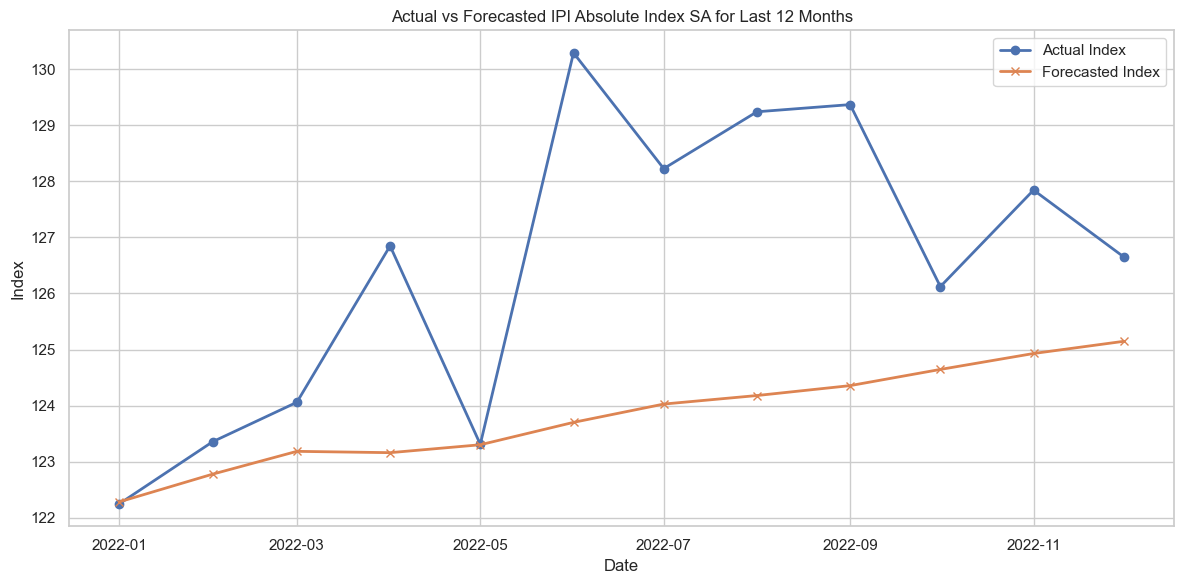

,actual,forecast
date,,
2022-01-01,122.249,122.282586
2022-02-01,123.355,122.776783
2022-03-01,124.059,123.183349
2022-04-01,126.849,123.159683
2022-05-01,123.309,123.300844
2022-06-01,130.293,123.700486
2022-07-01,128.228,124.026843
2022-08-01,129.242,124.179117
2022-09-01,129.370,124.356025


In [8]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_true, marker='o', label='Actual Index', linewidth=2)
plt.plot(forecast_df.index, forecast_df['ipi_abs_index_sa'], marker='x', label='Forecasted Index', linewidth=2)
plt.title('Actual vs Forecasted IPI Absolute Index SA for Last 12 Months')
plt.xlabel('Date')
plt.ylabel('Index')
plt.legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'actual': y_true,
    'forecast': y_pred
})
comparison